# Solar Eclipses

What is the average duration of total darkness during a total solar eclipse? When did the longest solar eclipse occur?

The file `solar-eclipses.csv` provides information on all solar eclipses from 1901 to 2100, leveraging the ability of scientists to accurately predict the timing and location of future eclipses.

A solar eclipse happens when the Moon moves between the Earth and the Sun, blocking the Sun's light either partially or completely. There are three primary types of solar eclipses:

1. Total Solar Eclipse: The Moon fully covers the Sun, casting a shadow on Earth and revealing the Sun's corona.

2. Partial Solar Eclipse: The Moon obscures only part of the Sun, creating a crescent-shaped appearance.

3. Annular Solar Eclipse: The Moon covers the center of the Sun, leaving a ring-like appearance, known as a "ring of fire," around the edges. This occurs when the Moon is too far from Earth to completely cover the Sun.

The `duration` variable indicates the length of time that the entire moon covers the sun.


In [ ]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'solar-eclipses.csv'.

# from google.colab import files
# uploaded = files.upload()

In [1]:
import pandas as pd
pd.set_option('display.max_colwidth', 1000)
df = pd.read_csv('solar-eclipses.csv')
df

,date,eclipse_type,magnitude,duration,region
0,05-18-1901,Total,1.068,06m29s,"s Asia, Australia, e Africa [Total: Indonesia, N Guinea, Madagascar]"
1,11-11-1901,Annular,0.922,11m01s,"ne Africa, Asia, w Europe [Annular: ne Africa, India, Sri Lanka, se Asia]"
2,04-08-1902,Partial,0.064,NaN,northern Canada
3,05-07-1902,Partial,0.859,NaN,"New Zealand, South Pacific"
4,10-31-1902,Partial,0.696,NaN,"c Asia, e Europe"
...,...,...,...,...,...
439,10-24-2098,Partial,0.006,NaN,Southern Ocean (near Antarctica)
440,03-21-2099,Annular,0.932,07m32s,"Australia, N.Z., Antarctica, N. America [Annular: Central Pacific]"
441,09-14-2099,Total,1.068,05m18s,"Americas, Africa [Total: Canada, U.S., Central Atlantic]"
442,03-10-2100,Annular,0.934,07m29s,"Australia, N. America [Annular: Central Pacific, U.S.]"


### Project Ideas:

- When did the longest solar eclipse occur? The longest total eclipse?
	- Hint: convert duration to seconds. You can use `str.replace('s', '')` to remove the 's' from the duration values.

- What is the average duration of total solar eclipses? 

- Show the next 10 solar eclipses?
	- Hint: convert date to datetime.


In [3]:
import pandas as pd

df = pd.read_csv('solar-eclipses.csv')

# remove rows with missing durations
df_duration = df.dropna(subset=['duration']).copy()

# remove 's'
df_duration['duration_clean'] = (
    df_duration['duration']
    .str.replace('s', '', regex=False)
)

# split minutes and seconds
df_duration[['Minutes', 'Seconds']] = (
    df_duration['duration_clean']
    .str.split('m', expand=True)
)

# convert to total seconds
df_duration['duration_seconds'] = (
    df_duration['Minutes'].astype(int) * 60 +
    df_duration['Seconds'].astype(int)
)

longest_eclipse = df_duration.loc[
    df_duration['duration_seconds'].idxmax()
]

# longest eclipse
print(longest_eclipse[['date', 'eclipse_type', 'duration']])

# longest total eclipse
total_eclipses = df_duration[
    df_duration['eclipse_type'] == 'Total'
]

longest_total = total_eclipses.loc[
    total_eclipses['duration_seconds'].idxmax()
]

print(longest_total[['date', 'eclipse_type', 'duration']])

# average duration of total eclipses
average_duration = total_eclipses['duration_seconds'].mean()

minutes = int(average_duration // 60)
seconds = int(average_duration % 60)

print(f"Average duration: {minutes}m {seconds}s")

df['date'] = pd.to_datetime(df['date'])

# today's date
today = pd.Timestamp.today()

# future eclipses
future_eclipses = df[df['date'] > today]

# next 10 eclipses
next_10 = future_eclipses.sort_values('date').head(10)

print(next_10[['date', 'eclipse_type', 'duration']])

date            12-14-1955
eclipse_type       Annular
duration            12m09s
Name: 126, dtype: object
date            06-20-1955
eclipse_type         Total
duration            07m08s
Name: 125, dtype: object
Average duration: 3m 31s
          date eclipse_type duration
277 2026-08-12        Total   02m18s
278 2027-02-06      Annular   07m51s
279 2027-08-02        Total   06m23s
280 2028-01-26      Annular   10m27s
281 2028-07-22        Total   05m10s
282 2029-01-14      Partial      NaN
283 2029-06-12      Partial      NaN
284 2029-07-11      Partial      NaN
285 2029-12-05      Partial      NaN
286 2030-06-01      Annular   05m21s


### Charts:

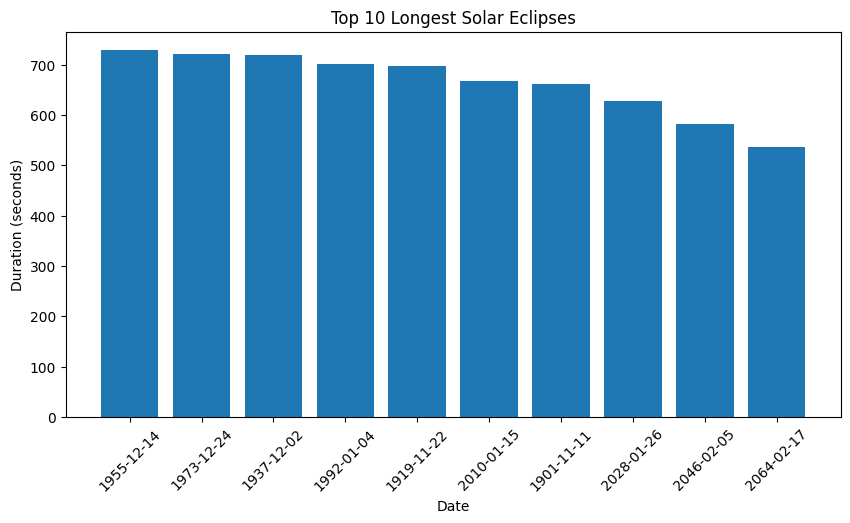

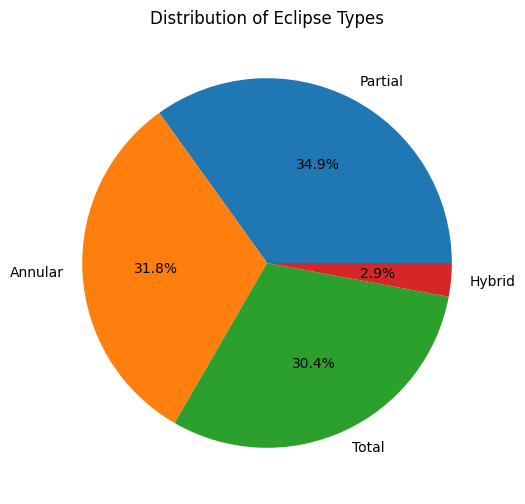

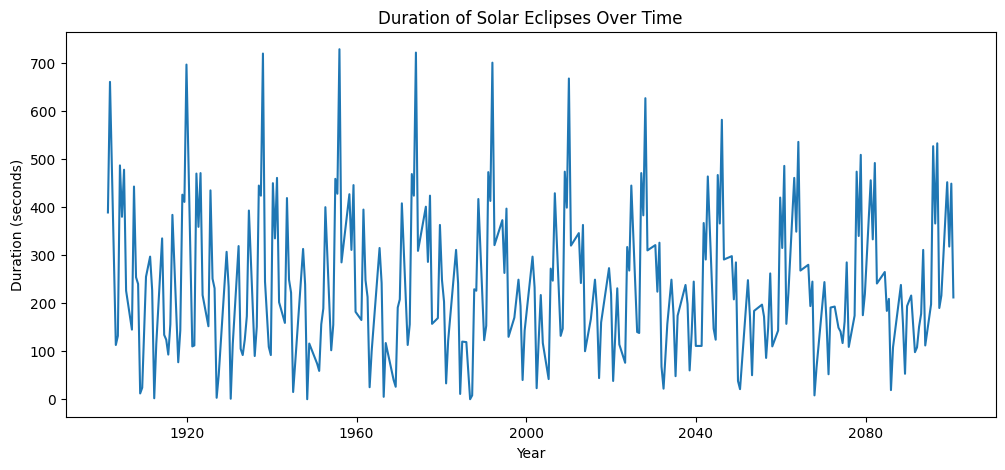

In [5]:
import matplotlib.pyplot as plt

# top 10 longest eclipses
top_10 = df_duration.sort_values(
    'duration_seconds',
    ascending=False
).head(10)

plt.figure(figsize=(10, 5))

plt.bar(
    top_10['date'].astype(str),
    top_10['duration_seconds']
)

plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Duration (seconds)')
plt.title('Top 10 Longest Solar Eclipses')

plt.show()

# eclipse types distribution
type_counts = df['eclipse_type'].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
)

plt.title('Distribution of Eclipse Types')

plt.show()

# duration over time

df_duration['date'] = pd.to_datetime(df_duration['date'])

sorted_df = df_duration.sort_values('date')

plt.figure(figsize=(12, 5))

plt.plot(
    sorted_df['date'],
    sorted_df['duration_seconds']
)

plt.xlabel('Year')
plt.ylabel('Duration (seconds)')
plt.title('Duration of Solar Eclipses Over Time')

plt.show()